In [1]:
%autosave 0

Autosave disabled


# Testing non-linear solvers on the Rosenbrock function

## Problem definition

In this notebook we show how to set a user-defined objective function and minimize it using different solvers.
The function understudy is the well-known convex Rosenbrock function. Its analytical form for the 2D case takes the following form:
\begin{equation}
\phi(x,y) = (1-x)^2 + 100 (y-x^2)^2,
\end{equation}
in which the unique global minimum is at $x=y=1$. The global minimum is inside a long, narrow, parabolic-shaped flat valley. To find the valley is trivial. To converge to the global minimum, however, is difficult. Hence, this function represents a good testing case for any non-linear optimization scheme.

In [2]:
#Loading necessary modules
import sys
sys.path.insert(0, "../python")
import pyVector as Vec
import pyOperator as Op
import pyProblem as Prblm
from pyStopper import BasicStopper as Stopper
from pyStepper import ParabolicStep as StepperPar
from pyStepper import CvSrchStep as StepperMT
from pyNonLinearSolver import NLCGsolver as NLCG
from pyNonLinearSolver import LBFGSsolver as LBFGS
import numpy as np
#Plotting library
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline
params = {
    'image.interpolation': 'nearest',
    'image.cmap': 'gray',
    'savefig.dpi': 300,  # to adjust notebook inline plot size
    'axes.labelsize': 12, # fontsize for x and y labels (was 10)
    'axes.titlesize': 12,
    'font.size': 12, # was 10
    'legend.fontsize': 12, # was 10
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
matplotlib.rcParams.update(params)

WARNING! DATAPATH not found. The folder /tmp will be used to write binary files


Let's first define the problem object. Our model vector is going to be $\mathbf{m} = [x \,, \, y]^T$. Since the libary assumes that the objective function is written in terms of some residual vector (i.e., $\phi(\mathbf{r}(\mathbf{m}))$, we will create a vector containing objective function as a single scalar value. 

In [3]:
class Rosenbrock_prblm(Prblm.Problem):
	"""
	   Rosenbrock function inverse problem
	   f(x,y) = (1 - x)^2 + 100*(y -x^2)^2
	   m = [x y]'
	   res = objective function value
	"""

	def __init__(self,x_initial,y_initial):
		"""Constructor of linear problem"""
		#Setting the bounds (if any)
		super(Rosenbrock_prblm,self).__init__(None,None)
		#Setting initial model
		self.model  = Vec.vectorIC(np.array((x_initial,y_initial)))
		self.dmodel = self.model.clone()
		self.dmodel.zero()
		#Gradient vector
		self.grad=self.dmodel.clone()
		#Residual vector
		self.res = Vec.vectorIC(np.array((0.,)))
		#Dresidual vector
		self.dres=self.res.clone()
		#Setting default variables
		self.setDefaults()
		self.linear=False
		return

	def objf(self,model):
		"""Objective function computation"""
		m = model.getNdArray() #Getting ndArray of the model
		obj = self.res.arr[0]
		return obj

	def resf(self,model):
		"""Residual function"""
		m = model.getNdArray() #Getting ndArray of the model
		self.res.getNdArray()[0] = (1.0 - m[0])*(1.0 - m[0]) + 100.0 * (m[1] - m[0]*m[0]) * (m[1] - m[0]*m[0])
		return self.res

	def gradf(self,model,res):
		"""Gradient computation"""
		m = model.getNdArray() #Getting ndArray of the model
		self.grad.getNdArray()[0] = - 2.0 * (1.0 - m[0]) - 400.0 * m[0] * (m[1] - m[0]*m[0])
		self.grad.getNdArray()[1] = 200.0 * (m[1] - m[0]*m[0])
		return self.grad

	def dresf(self,model,dmodel):
		"""Linear variation of the objective function value"""
		m = model.getNdArray() #Getting ndArray of the model
		dm = dmodel.getNdArray() #Getting ndArray of the model
		self.dres.arr[0] = (- 2.0 * (1.0 - m[0]) - 400.0 * m[0] * (m[1] - m[0]*m[0]))* dm[0] + (200.0 * (m[1] - m[0]*m[0])) * dm[1]
		return self.dres

### Instantiation of the inverse problem and of the various solvers

In [4]:
#Starting point for all the optimization problem
x_init = -1.0
y_init = -1.0
#Testing solver on Rosenbrock function
Ros_prob = Rosenbrock_prblm(x_init,y_init)

Before running any inversion, let's compute the objective function for different values of $x$ and $y$. This step will be useful when we want to plot the optimization path taken by the various tested algorithms.

In [5]:
#Computing the objective function for plotting
x_samples = np.linspace(-1.5,1.5,1000)
y_samples = np.linspace(3,-1.5,1000)
obj_ros = Vec.vectorIC(np.zeros((len(x_samples),len(y_samples))))
obj_ros_np = obj_ros.getNdArray()
model_test = Vec.vectorIC(np.array((0.0,0.0)))
model_test_np = model_test.getNdArray()
for ix,x_value in enumerate(x_samples):
	for iy,y_value in enumerate(y_samples):
		model_test_np[0] = x_value
		model_test_np[1] = y_value
		obj_ros_np[ix,iy]=Ros_prob.get_obj(model_test)

First we test a non-linear conjugate-gradient method in which a parabolic stepper with three-point interpolation is used. 

In [6]:
niter = 1000
Stop  = Stopper(niter=niter,tolr=1e-32,tolg=1e-32)
NLCGsolver = NLCG(Stop)
Ros_prob = Rosenbrock_prblm(x_init,y_init) #Resetting the problem
NLCGsolver.setDefaults(save_obj=True,save_model=True)
NLCGsolver.run(Ros_prob,verbose=True)
#Converting sampled points to arrays for plotting
x_smpld=[]
y_smpld=[]
for iter in range(len(NLCGsolver.model)):
    x_smpld.append(NLCGsolver.model[iter].getNdArray()[0])
    y_smpld.append(NLCGsolver.model[iter].getNdArray()[1])

##########################################################################################
			NON-LINEAR CONJUGATE GRADIENT SOLVER 
	Restart folder: /tmp/restart_2020-07-15T19-46-24.581502/
	Conjugate method used: FR
##########################################################################################

iter = 0000, obj = 4.04000e+02, resnorm = 4.04e+02, gradnorm = 8.98e+02, feval = 1, geval = 1
iter = 0001, obj = 4.00632e+01, resnorm = 4.01e+01, gradnorm = 1.33e+02, feval = 4, geval = 2
iter = 0002, obj = 1.75421e+00, resnorm = 1.75e+00, gradnorm = 1.87e+01, feval = 7, geval = 3
iter = 0003, obj = 8.70442e-01, resnorm = 8.70e-01, gradnorm = 1.88e+00, feval = 10, geval = 4
iter = 0004, obj = 8.39754e-01, resnorm = 8.40e-01, gradnorm = 1.81e+00, feval = 13, geval = 5
iter = 0005, obj = 7.38115e-01, resnorm = 7.38e-01, gradnorm = 2.27e+00, feval = 16, geval = 6
iter = 0006, obj = 5.41088e-01, resnorm = 5.41e-01, gradnorm = 4.40e+00, feval = 19, geval = 7
iter = 0007, obj = 4.82647e-0

iter = 0090, obj = 9.55015e-14, resnorm = 9.55e-14, gradnorm = 7.53e-07, feval = 282, geval = 91
iter = 0091, obj = 9.21970e-14, resnorm = 9.22e-14, gradnorm = 1.87e-06, feval = 285, geval = 92
iter = 0092, obj = 7.13506e-14, resnorm = 7.14e-14, gradnorm = 4.21e-06, feval = 288, geval = 93
iter = 0093, obj = 2.80570e-14, resnorm = 2.81e-14, gradnorm = 3.82e-06, feval = 291, geval = 94
iter = 0094, obj = 1.23092e-14, resnorm = 1.23e-14, gradnorm = 1.53e-06, feval = 294, geval = 95
iter = 0095, obj = 1.01904e-14, resnorm = 1.02e-14, gradnorm = 5.25e-07, feval = 297, geval = 96
iter = 0096, obj = 9.93374e-15, resnorm = 9.93e-15, gradnorm = 2.18e-07, feval = 300, geval = 97
iter = 0097, obj = 9.87012e-15, resnorm = 9.87e-15, gradnorm = 1.81e-07, feval = 303, geval = 98
iter = 0098, obj = 9.74733e-15, resnorm = 9.75e-15, gradnorm = 3.48e-07, feval = 306, geval = 99
iter = 0099, obj = 8.94727e-15, resnorm = 8.95e-15, gradnorm = 9.04e-07, feval = 309, geval = 100
iter = 0100, obj = 5.31282e-1

iter = 0197, obj = 2.80539e-29, resnorm = 2.81e-29, gradnorm = 1.93e-13, feval = 614, geval = 198
iter = 0198, obj = 1.91792e-29, resnorm = 1.92e-29, gradnorm = 9.26e-14, feval = 617, geval = 199
iter = 0199, obj = 1.59744e-29, resnorm = 1.60e-29, gradnorm = 7.99e-15, feval = 620, geval = 200
Stepper couldn't find a proper step size, will terminate solver
##########################################################################################
			NON-LINEAR CONJUGATE GRADIENT SOLVER end
##########################################################################################



Let's plot the optimization path taken by the algorithm, which converged to the global minimum in 199 iterations using a parabolic stepper.

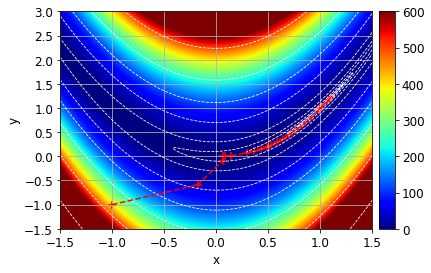

In [7]:
fig,ax=plt.subplots()
# im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[-1.5,1.5,-1.0,3.0])
plt.scatter(x_smpld,y_smpld,color='red',s=50,marker="+")
plt.plot(x_smpld,y_smpld,"--",color='red')
im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[1.5,-1.5,-1.5,3.0])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cs = plt.contour(obj_ros_np.T,levels=[0.05,0.1,0.5,2,10,50,125,250,500,1000],extent=[-1.5,1.5,3.0,-1.5],
                 colors="white",linewidths=(0.8,),linestyles=('--'))
plt.gca().invert_xaxis()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
ax.set_aspect('auto')
plt.savefig('Rosen-NLCG.pdf', format='pdf', dpi=300, bbox_inches='tight')

For the second test, we will test the steppest-descent approach using the same stepper.

In [8]:
NLSDsolver = NLCG(Stop,beta_type="SD")
Ros_prob = Rosenbrock_prblm(x_init,y_init) #Resetting the problem
NLSDsolver.setDefaults(save_obj=True,save_model=True)
NLSDsolver.run(Ros_prob,verbose=True)
#Converting sampled points to arrays for plotting
x_smpld=[]
y_smpld=[]
for iter in range(len(NLSDsolver.model)):
    x_smpld.append(NLSDsolver.model[iter].getNdArray()[0])
    y_smpld.append(NLSDsolver.model[iter].getNdArray()[1])

##########################################################################################
			NON-LINEAR STEEPEST-DESCENT SOLVER 
	Restart folder: /tmp/restart_2020-07-15T19-46-30.836682/
##########################################################################################

iter = 0000, obj = 4.04000e+02, resnorm = 4.04e+02, gradnorm = 8.98e+02, feval = 1, geval = 1
iter = 0001, obj = 4.00632e+01, resnorm = 4.01e+01, gradnorm = 1.33e+02, feval = 4, geval = 2
iter = 0002, obj = 1.38669e+00, resnorm = 1.39e+00, gradnorm = 1.31e+01, feval = 7, geval = 3
iter = 0003, obj = 9.47697e-01, resnorm = 9.48e-01, gradnorm = 1.97e+00, feval = 10, geval = 4
iter = 0004, obj = 9.09671e-01, resnorm = 9.10e-01, gradnorm = 1.93e+00, feval = 13, geval = 5
iter = 0005, obj = 5.52153e-01, resnorm = 5.52e-01, gradnorm = 8.04e+00, feval = 16, geval = 6
iter = 0006, obj = 4.41805e-01, resnorm = 4.42e-01, gradnorm = 1.10e+00, feval = 23, geval = 7
iter = 0007, obj = 4.33636e-01, resnorm = 4.34e-01, gradno

iter = 0128, obj = 1.14157e-01, resnorm = 1.14e-01, gradnorm = 7.66e-01, feval = 389, geval = 129
iter = 0129, obj = 1.13420e-01, resnorm = 1.13e-01, gradnorm = 4.77e-01, feval = 392, geval = 130
iter = 0130, obj = 1.12692e-01, resnorm = 1.13e-01, gradnorm = 7.59e-01, feval = 395, geval = 131
iter = 0131, obj = 1.11971e-01, resnorm = 1.12e-01, gradnorm = 4.73e-01, feval = 398, geval = 132
iter = 0132, obj = 1.11258e-01, resnorm = 1.11e-01, gradnorm = 7.53e-01, feval = 401, geval = 133
iter = 0133, obj = 1.10551e-01, resnorm = 1.11e-01, gradnorm = 4.69e-01, feval = 404, geval = 134
iter = 0134, obj = 1.09853e-01, resnorm = 1.10e-01, gradnorm = 7.47e-01, feval = 407, geval = 135
iter = 0135, obj = 1.09161e-01, resnorm = 1.09e-01, gradnorm = 4.65e-01, feval = 410, geval = 136
iter = 0136, obj = 1.08478e-01, resnorm = 1.08e-01, gradnorm = 7.40e-01, feval = 413, geval = 137
iter = 0137, obj = 1.07800e-01, resnorm = 1.08e-01, gradnorm = 4.62e-01, feval = 416, geval = 138
iter = 0138, obj = 1

iter = 0264, obj = 5.59122e-02, resnorm = 5.59e-02, gradnorm = 4.86e-01, feval = 797, geval = 265
iter = 0265, obj = 5.56661e-02, resnorm = 5.57e-02, gradnorm = 3.05e-01, feval = 800, geval = 266
iter = 0266, obj = 5.54218e-02, resnorm = 5.54e-02, gradnorm = 4.83e-01, feval = 803, geval = 267
iter = 0267, obj = 5.51789e-02, resnorm = 5.52e-02, gradnorm = 3.03e-01, feval = 806, geval = 268
iter = 0268, obj = 5.49376e-02, resnorm = 5.49e-02, gradnorm = 4.80e-01, feval = 809, geval = 269
iter = 0269, obj = 5.46977e-02, resnorm = 5.47e-02, gradnorm = 3.01e-01, feval = 812, geval = 270
iter = 0270, obj = 5.44595e-02, resnorm = 5.45e-02, gradnorm = 4.78e-01, feval = 815, geval = 271
iter = 0271, obj = 5.42226e-02, resnorm = 5.42e-02, gradnorm = 3.00e-01, feval = 818, geval = 272
iter = 0272, obj = 5.39873e-02, resnorm = 5.40e-02, gradnorm = 4.75e-01, feval = 821, geval = 273
iter = 0273, obj = 5.37533e-02, resnorm = 5.38e-02, gradnorm = 2.98e-01, feval = 824, geval = 274
iter = 0274, obj = 5

iter = 0396, obj = 3.31088e-02, resnorm = 3.31e-02, gradnorm = 3.55e-01, feval = 1193, geval = 397
iter = 0397, obj = 3.29893e-02, resnorm = 3.30e-02, gradnorm = 2.24e-01, feval = 1196, geval = 398
iter = 0398, obj = 3.28704e-02, resnorm = 3.29e-02, gradnorm = 3.54e-01, feval = 1199, geval = 399
iter = 0399, obj = 3.27521e-02, resnorm = 3.28e-02, gradnorm = 2.23e-01, feval = 1202, geval = 400
iter = 0400, obj = 3.26343e-02, resnorm = 3.26e-02, gradnorm = 3.52e-01, feval = 1205, geval = 401
iter = 0401, obj = 3.25171e-02, resnorm = 3.25e-02, gradnorm = 2.22e-01, feval = 1208, geval = 402
iter = 0402, obj = 3.24004e-02, resnorm = 3.24e-02, gradnorm = 3.51e-01, feval = 1211, geval = 403
iter = 0403, obj = 3.22843e-02, resnorm = 3.23e-02, gradnorm = 2.21e-01, feval = 1214, geval = 404
iter = 0404, obj = 3.21688e-02, resnorm = 3.22e-02, gradnorm = 3.49e-01, feval = 1217, geval = 405
iter = 0405, obj = 3.20537e-02, resnorm = 3.21e-02, gradnorm = 2.20e-01, feval = 1220, geval = 406
iter = 040

iter = 0480, obj = 2.47643e-02, resnorm = 2.48e-02, gradnorm = 3.00e-01, feval = 1445, geval = 481
iter = 0481, obj = 2.46824e-02, resnorm = 2.47e-02, gradnorm = 1.89e-01, feval = 1448, geval = 482
iter = 0482, obj = 2.46009e-02, resnorm = 2.46e-02, gradnorm = 2.99e-01, feval = 1451, geval = 483
iter = 0483, obj = 2.45197e-02, resnorm = 2.45e-02, gradnorm = 1.89e-01, feval = 1454, geval = 484
iter = 0484, obj = 2.44388e-02, resnorm = 2.44e-02, gradnorm = 2.98e-01, feval = 1457, geval = 485
iter = 0485, obj = 2.43583e-02, resnorm = 2.44e-02, gradnorm = 1.88e-01, feval = 1460, geval = 486
iter = 0486, obj = 2.42781e-02, resnorm = 2.43e-02, gradnorm = 2.97e-01, feval = 1463, geval = 487
iter = 0487, obj = 2.41983e-02, resnorm = 2.42e-02, gradnorm = 1.87e-01, feval = 1466, geval = 488
iter = 0488, obj = 2.41188e-02, resnorm = 2.41e-02, gradnorm = 2.96e-01, feval = 1469, geval = 489
iter = 0489, obj = 2.40396e-02, resnorm = 2.40e-02, gradnorm = 1.86e-01, feval = 1472, geval = 490
iter = 049

iter = 0615, obj = 1.62170e-02, resnorm = 1.62e-02, gradnorm = 1.50e-01, feval = 1850, geval = 616
iter = 0616, obj = 1.61688e-02, resnorm = 1.62e-02, gradnorm = 2.36e-01, feval = 1853, geval = 617
iter = 0617, obj = 1.61206e-02, resnorm = 1.61e-02, gradnorm = 1.49e-01, feval = 1856, geval = 618
iter = 0618, obj = 1.60727e-02, resnorm = 1.61e-02, gradnorm = 2.35e-01, feval = 1859, geval = 619
iter = 0619, obj = 1.60250e-02, resnorm = 1.60e-02, gradnorm = 1.49e-01, feval = 1862, geval = 620
iter = 0620, obj = 1.59774e-02, resnorm = 1.60e-02, gradnorm = 2.35e-01, feval = 1865, geval = 621
iter = 0621, obj = 1.59300e-02, resnorm = 1.59e-02, gradnorm = 1.48e-01, feval = 1868, geval = 622
iter = 0622, obj = 1.58828e-02, resnorm = 1.59e-02, gradnorm = 2.34e-01, feval = 1871, geval = 623
iter = 0623, obj = 1.58357e-02, resnorm = 1.58e-02, gradnorm = 1.48e-01, feval = 1874, geval = 624
iter = 0624, obj = 1.57888e-02, resnorm = 1.58e-02, gradnorm = 2.33e-01, feval = 1877, geval = 625
iter = 062

iter = 0747, obj = 1.11077e-02, resnorm = 1.11e-02, gradnorm = 1.22e-01, feval = 2246, geval = 748
iter = 0748, obj = 1.10770e-02, resnorm = 1.11e-02, gradnorm = 1.92e-01, feval = 2249, geval = 749
iter = 0749, obj = 1.10464e-02, resnorm = 1.10e-02, gradnorm = 1.21e-01, feval = 2252, geval = 750
iter = 0750, obj = 1.10160e-02, resnorm = 1.10e-02, gradnorm = 1.91e-01, feval = 2255, geval = 751
iter = 0751, obj = 1.09856e-02, resnorm = 1.10e-02, gradnorm = 1.21e-01, feval = 2258, geval = 752
iter = 0752, obj = 1.09554e-02, resnorm = 1.10e-02, gradnorm = 1.91e-01, feval = 2261, geval = 753
iter = 0753, obj = 1.09252e-02, resnorm = 1.09e-02, gradnorm = 1.20e-01, feval = 2264, geval = 754
iter = 0754, obj = 1.08952e-02, resnorm = 1.09e-02, gradnorm = 1.90e-01, feval = 2267, geval = 755
iter = 0755, obj = 1.08652e-02, resnorm = 1.09e-02, gradnorm = 1.20e-01, feval = 2270, geval = 756
iter = 0756, obj = 1.08353e-02, resnorm = 1.08e-02, gradnorm = 1.89e-01, feval = 2273, geval = 757
iter = 075

iter = 0830, obj = 8.86985e-03, resnorm = 8.87e-03, gradnorm = 1.70e-01, feval = 2495, geval = 831
iter = 0831, obj = 8.84629e-03, resnorm = 8.85e-03, gradnorm = 1.07e-01, feval = 2498, geval = 832
iter = 0832, obj = 8.82280e-03, resnorm = 8.82e-03, gradnorm = 1.69e-01, feval = 2501, geval = 833
iter = 0833, obj = 8.79938e-03, resnorm = 8.80e-03, gradnorm = 1.07e-01, feval = 2504, geval = 834
iter = 0834, obj = 8.77604e-03, resnorm = 8.78e-03, gradnorm = 1.69e-01, feval = 2507, geval = 835
iter = 0835, obj = 8.75277e-03, resnorm = 8.75e-03, gradnorm = 1.07e-01, feval = 2510, geval = 836
iter = 0836, obj = 8.72957e-03, resnorm = 8.73e-03, gradnorm = 1.68e-01, feval = 2513, geval = 837
iter = 0837, obj = 8.70644e-03, resnorm = 8.71e-03, gradnorm = 1.07e-01, feval = 2516, geval = 838
iter = 0838, obj = 8.68339e-03, resnorm = 8.68e-03, gradnorm = 1.68e-01, feval = 2519, geval = 839
iter = 0839, obj = 8.66040e-03, resnorm = 8.66e-03, gradnorm = 1.06e-01, feval = 2522, geval = 840
iter = 084

iter = 0936, obj = 6.73012e-03, resnorm = 6.73e-03, gradnorm = 1.46e-01, feval = 2813, geval = 937
iter = 0937, obj = 6.71296e-03, resnorm = 6.71e-03, gradnorm = 9.27e-02, feval = 2816, geval = 938
iter = 0938, obj = 6.69586e-03, resnorm = 6.70e-03, gradnorm = 1.46e-01, feval = 2819, geval = 939
iter = 0939, obj = 6.67880e-03, resnorm = 6.68e-03, gradnorm = 9.24e-02, feval = 2822, geval = 940
iter = 0940, obj = 6.66180e-03, resnorm = 6.66e-03, gradnorm = 1.46e-01, feval = 2825, geval = 941
iter = 0941, obj = 6.64484e-03, resnorm = 6.64e-03, gradnorm = 9.22e-02, feval = 2828, geval = 942
iter = 0942, obj = 6.62793e-03, resnorm = 6.63e-03, gradnorm = 1.45e-01, feval = 2831, geval = 943
iter = 0943, obj = 6.61107e-03, resnorm = 6.61e-03, gradnorm = 9.19e-02, feval = 2834, geval = 944
iter = 0944, obj = 6.59426e-03, resnorm = 6.59e-03, gradnorm = 1.45e-01, feval = 2837, geval = 945
iter = 0945, obj = 6.57750e-03, resnorm = 6.58e-03, gradnorm = 9.17e-02, feval = 2840, geval = 946
iter = 094

Let's again plot the optimization path. In this case, the algorithm finds only falls close to the vicinity of the global minimum but does not reach even after 1000 iteration. In the figure below, we can see that the algorithm is sampling most of the objective function within the parabolic valley.

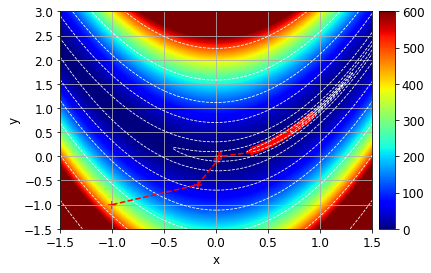

In [9]:
fig,ax=plt.subplots()
# im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[-1.5,1.5,-1.0,3.0])
plt.scatter(x_smpld,y_smpld,color='red',s=50,marker="+")
plt.plot(x_smpld,y_smpld,"--",color='red')
im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[1.5,-1.5,-1.5,3.0])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cs = plt.contour(obj_ros_np.T,levels=[0.05,0.1,0.5,2,10,50,125,250,500,1000],extent=[-1.5,1.5,3.0,-1.5],
                 colors="white",linewidths=(0.8,),linestyles=('--'))
plt.gca().invert_xaxis()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
ax.set_aspect('auto')
plt.savefig('Rosen-NLSD.pdf', format='pdf', dpi=300, bbox_inches='tight')

In the third test, let's apply the BFGS algorithm to find the function's global minimum.

In [10]:
ParabStep = StepperPar() #Again we use the same parabolic stepper as before
BFGSsolver = LBFGS(Stop,stepper=ParabStep)
Ros_prob = Rosenbrock_prblm(x_init,y_init) #Resetting the problem
BFGSsolver.setDefaults(save_obj=True,save_model=True)
BFGSsolver.run(Ros_prob,verbose=True)
#Converting sampled points to arrays for plotting
x_smpld=[]
y_smpld=[]
for iter in range(len(BFGSsolver.model)):
    x_smpld.append(BFGSsolver.model[iter].getNdArray()[0])
    y_smpld.append(BFGSsolver.model[iter].getNdArray()[1])

##########################################################################################
Broyden-Fletcher-Goldfarb-Shanno (BFGS) algorithm 
Restart folder: /tmp/restart_2020-07-15T19-46-41.547756/
##########################################################################################

iter = 0000, obj = 4.04000e+02, resnorm = 4.04e+02, gradnorm = 8.98e+02, feval = 1, geval = 1
iter = 0001, obj = 4.00632e+01, resnorm = 4.01e+01, gradnorm = 1.33e+02, feval = 4, geval = 2
iter = 0002, obj = 1.47062e+00, resnorm = 1.47e+00, gradnorm = 1.50e+01, feval = 7, geval = 3
iter = 0003, obj = 8.58417e-01, resnorm = 8.58e-01, gradnorm = 2.09e+00, feval = 10, geval = 4
iter = 0004, obj = 8.50009e-01, resnorm = 8.50e-01, gradnorm = 2.01e+00, feval = 13, geval = 5
iter = 0005, obj = 7.40017e-01, resnorm = 7.40e-01, gradnorm = 8.34e+00, feval = 16, geval = 6
iter = 0006, obj = 6.72390e-01, resnorm = 6.72e-01, gradnorm = 2.65e+00, feval = 19, geval = 7
iter = 0007, obj = 5.62078e-01, resnorm = 5.62e

The algorithm has precisely reached the global minimum in 24 iterations. We can clearly see that it is able to find an approximation of the local curvature of the objective function. In fact, it needs to sample very few points within the parabolic-shaped valley. 

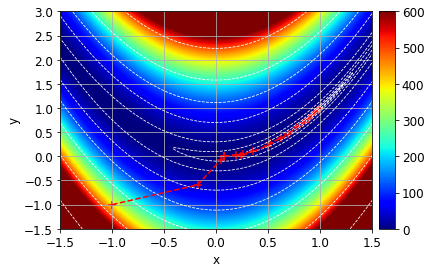

In [11]:
fig,ax=plt.subplots()
# im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[-1.5,1.5,-1.0,3.0])
plt.scatter(x_smpld,y_smpld,color='red',s=50,marker="+")
plt.plot(x_smpld,y_smpld,"--",color='red')
im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[1.5,-1.5,-1.5,3.0])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cs = plt.contour(obj_ros_np.T,levels=[0.05,0.1,0.5,2,10,50,125,250,500,1000],extent=[-1.5,1.5,3.0,-1.5],
                 colors="white",linewidths=(0.8,),linestyles=('--'))
plt.gca().invert_xaxis()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
ax.set_aspect('auto')
plt.savefig('Rosen-BFGS.pdf', format='pdf', dpi=300, bbox_inches='tight')

Finally, let's test again the BFGS method but this time employing the line-search algorithm proposed by More and Thuente (1994). Their line-search method uses a backeting approach in which the strong Wolfe conditions are verified for the tested point. In this case, if these conditons are met, then the method was successful.

In [12]:
BFGSsolver = LBFGS(Stop)
Ros_prob = Rosenbrock_prblm(x_init,y_init) #Resetting the problem
BFGSsolver.setDefaults(save_obj=True,save_model=True)
BFGSsolver.run(Ros_prob,verbose=True)
#Converting sampled points to arrays for plotting
x_smpld=[]
y_smpld=[]
for iter in range(len(BFGSsolver.model)):
    x_smpld.append(BFGSsolver.model[iter].getNdArray()[0])
    y_smpld.append(BFGSsolver.model[iter].getNdArray()[1])

##########################################################################################
Broyden-Fletcher-Goldfarb-Shanno (BFGS) algorithm 
Restart folder: /tmp/restart_2020-07-15T19-46-47.971415/
##########################################################################################

iter = 0000, obj = 4.04000e+02, resnorm = 4.04e+02, gradnorm = 8.98e+02, feval = 1, geval = 1
iter = 0001, obj = 1.36247e+02, resnorm = 1.36e+02, gradnorm = 3.63e+02, feval = 2, geval = 2
iter = 0002, obj = 5.53769e+01, resnorm = 5.54e+01, gradnorm = 1.81e+02, feval = 3, geval = 3
iter = 0003, obj = 1.77234e+01, resnorm = 1.77e+01, gradnorm = 8.53e+01, feval = 4, geval = 4
iter = 0004, obj = 4.91376e+00, resnorm = 4.91e+00, gradnorm = 3.96e+01, feval = 5, geval = 5
iter = 0005, obj = 1.35174e+00, resnorm = 1.35e+00, gradnorm = 1.43e+01, feval = 6, geval = 6
iter = 0006, obj = 7.80486e-01, resnorm = 7.80e-01, gradnorm = 2.83e+00, feval = 7, geval = 7
iter = 0007, obj = 7.38601e-01, resnorm = 7.39e-01,

We can see that the algorithm has reached the global minimum in 36 iterations. However, since we employed a different stepping method, in which no parabolic interpolation is used during the optimization, the algorithm had to perfom only 41 objective function evaluations as opposed to 73 necessary by the BFGS method when the parabolic stepper was the line-search algorithm of choice.

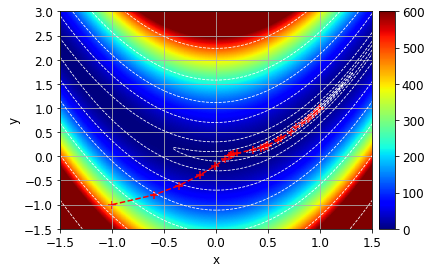

In [13]:
fig,ax=plt.subplots()
# im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[-1.5,1.5,-1.0,3.0])
plt.scatter(x_smpld,y_smpld,color='red',s=50,marker="+")
plt.plot(x_smpld,y_smpld,"--",color='red')
im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[1.5,-1.5,-1.5,3.0])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cs = plt.contour(obj_ros_np.T,levels=[0.05,0.1,0.5,2,10,50,125,250,500,1000],extent=[-1.5,1.5,3.0,-1.5],
                 colors="white",linewidths=(0.8,),linestyles=('--'))
plt.gca().invert_xaxis()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
ax.set_aspect('auto')
plt.savefig('Rosen-BFGS.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [14]:
LBFGSsolver = LBFGS(Stop, m_steps=5)
Ros_prob = Rosenbrock_prblm(x_init,y_init) #Resetting the problem
LBFGSsolver.setDefaults(save_obj=True,save_model=True)
LBFGSsolver.run(Ros_prob,verbose=True)
#Converting sampled points to arrays for plotting
x_smpld=[]
y_smpld=[]
for iter in range(len(BFGSsolver.model)):
    x_smpld.append(BFGSsolver.model[iter].getNdArray()[0])
    y_smpld.append(BFGSsolver.model[iter].getNdArray()[1])

##########################################################################################
Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS) algorithm 
Maximum number of steps to be used for Hessian inverse estimation: 5 
Restart folder: /tmp/restart_2020-07-15T19-46-53.812465/
##########################################################################################

iter = 0000, obj = 4.04000e+02, resnorm = 4.04e+02, gradnorm = 8.98e+02, feval = 1, geval = 1
iter = 0001, obj = 1.36247e+02, resnorm = 1.36e+02, gradnorm = 3.63e+02, feval = 2, geval = 2
iter = 0002, obj = 5.53769e+01, resnorm = 5.54e+01, gradnorm = 1.81e+02, feval = 3, geval = 3
iter = 0003, obj = 1.77234e+01, resnorm = 1.77e+01, gradnorm = 8.53e+01, feval = 4, geval = 4
iter = 0004, obj = 4.91376e+00, resnorm = 4.91e+00, gradnorm = 3.96e+01, feval = 5, geval = 5
iter = 0005, obj = 1.35174e+00, resnorm = 1.35e+00, gradnorm = 1.43e+01, feval = 6, geval = 6
iter = 0006, obj = 7.80486e-01, resnorm = 7.80e-01, gradno

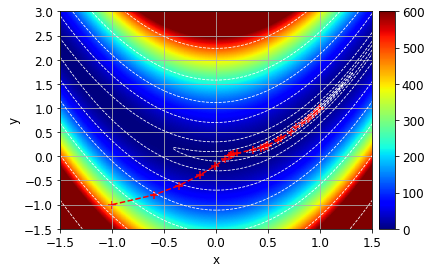

In [15]:
fig,ax=plt.subplots()
# im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[-1.5,1.5,-1.0,3.0])
plt.scatter(x_smpld,y_smpld,color='red',s=50,marker="+")
plt.plot(x_smpld,y_smpld,"--",color='red')
im=plt.imshow(obj_ros_np.T,cmap='jet',vmin=0.0,vmax=600,extent=[1.5,-1.5,-1.5,3.0])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cs = plt.contour(obj_ros_np.T,levels=[0.05,0.1,0.5,2,10,50,125,250,500,1000],extent=[-1.5,1.5,3.0,-1.5],
                 colors="white",linewidths=(0.8,),linestyles=('--'))
plt.gca().invert_xaxis()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
ax.set_aspect('auto')
plt.savefig('Rosen-LBFGS.pdf', format='pdf', dpi=300, bbox_inches='tight')

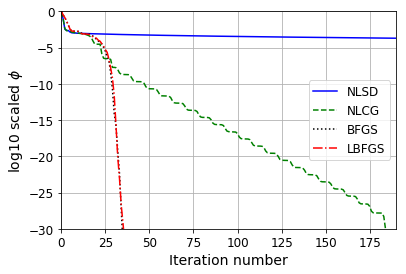

In [19]:
objNLSD = NLSDsolver.obj
objNLCG = NLCGsolver.obj
objBFGS = BFGSsolver.obj
objLBFGS = LBFGSsolver.obj
#Plotting convergence curves
fig,ax=plt.subplots()
plt.plot(range(len(objNLSD)),np.log10(objNLSD/objNLSD[0]+1e-40),'b-',label='NLSD')
plt.plot(range(len(objNLCG)),np.log10(objNLCG/objNLCG[0]+1e-40),'g--',label='NLCG')
plt.plot(range(len(objBFGS)),np.log10(objBFGS/objBFGS[0]+1e-40),'k:',label='BFGS')
plt.plot(range(len(objLBFGS)),np.log10(objLBFGS/objLBFGS[0]+1e-40),'r-.',label='LBFGS')
plt.grid()
# plt.title("Convergence curves")
plt.xlabel("Iteration number", fontsize=14)
plt.ylabel("log10 scaled $\phi$", fontsize=14)
ax.legend()
plt.xlim(0,190)
_=plt.ylim(-30,0)
plt.savefig('Rosen-conv.pdf', format='pdf', dpi=300, bbox_inches='tight')